## Crop EDA

**Purpose:** We inspect the extracted crop dataset visually and statistically so we understand its class balance, split composition, crop geometry, and modeling implications before training.

**Notebook Rules**
- We keep logic inside `src/`.
- We use this notebook for visual and statistical inspection.

In [1]:
# We set up the project path, import the shared config and utilities, and print the main project summary.

from pathlib import Path
import sys

currentDir = Path.cwd().resolve()
projectRoot = currentDir.parent if currentDir.name == "notebooks" else currentDir

if str(projectRoot) not in sys.path:
    sys.path.append(str(projectRoot))

from src.config import projectConfig
from src.utils import applyPlotStyle, ensureProjectDirs, printProjectSummary, setGlobalSeed

setGlobalSeed(projectConfig.seed)
ensureProjectDirs(projectConfig)
applyPlotStyle()
printProjectSummary(projectConfig)

projectRoot: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis
seed: 27
device: mps
imageDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/JPEGImages
annotationDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/Annotations
splitFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/train_val_test_split.txt
classFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/class_definitions.txt
cropsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataProcessed/crops
metricsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics


In [2]:
# We load the crop-build summary JSON so this notebook stays self-contained and reproducible.

import json

cropBuildSummaryPath = projectConfig.manifestsDir / "cropBuildSummary.json"

with open(cropBuildSummaryPath, "r", encoding="utf-8") as jsonFile:
    cropBuildSummary = json.load(jsonFile)

cropBuildSummary

{'cropPadding': 0,
 'cropCount': 1584,
 'uniqueSourceImageCount': 1065,
 'classCount': 6,
 'subsetCount': 3,
 'mismatchCropCount': 367,
 'exactDuplicateCropCount': 4,
 'crossSplitDuplicateCropCount': 2,
 'minCropWidth': 19,
 'maxCropWidth': 1012,
 'minCropHeight': 22,
 'maxCropHeight': 1022}

### Planned EDA Figures

In this notebook, we will inspect:
- crop counts by class
- crop counts by split
- class composition across splits
- crop width, height, and area distributions
- duplicate-risk counts
- representative crop examples by class

In [3]:
# We load the crop manifest and the main crop-level summary tables that we will use throughout this notebook.

import pandas as pd

cropManifestPath = projectConfig.manifestsDir / "cropManifest.csv"
cropClassCountsPath = projectConfig.manifestsDir / "cropClassCounts.csv"
cropSplitCountsPath = projectConfig.manifestsDir / "cropSplitCounts.csv"
cropClassBySplitCountsPath = projectConfig.manifestsDir / "cropClassBySplitCounts.csv"

cropManifestDf = pd.read_csv(cropManifestPath)
cropClassCountsDf = pd.read_csv(cropClassCountsPath)
cropSplitCountsDf = pd.read_csv(cropSplitCountsPath)
cropClassBySplitCountsDf = pd.read_csv(cropClassBySplitCountsPath)

cropEdaFigureDir = projectConfig.figuresDir / "cropEDA"

### Figure 1 — Crop Counts by Class

We first inspect the overall crop count per defect class so we can see the class balance clearly before modeling.

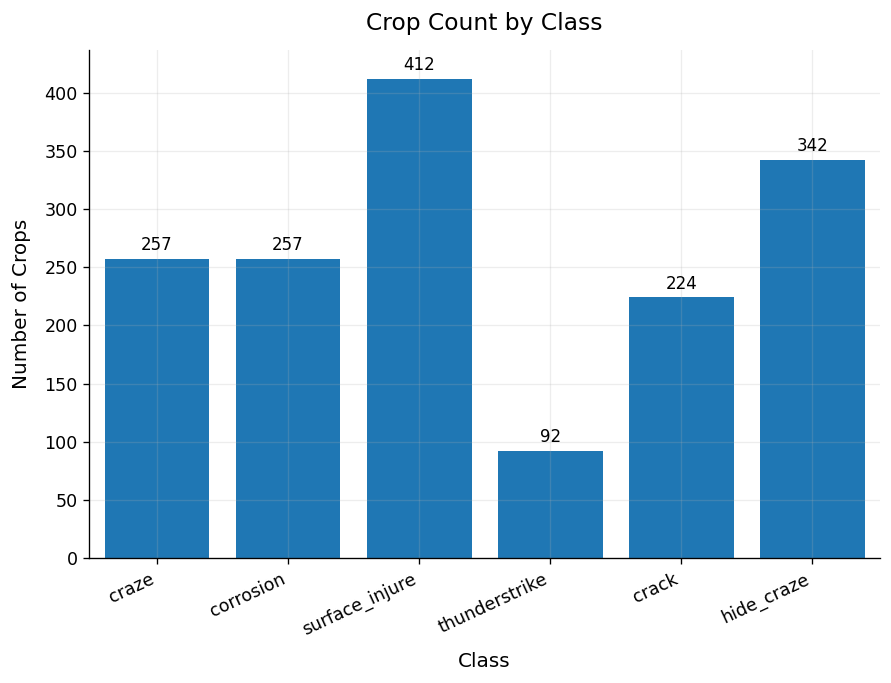

In [4]:
# We display the crop counts by class as a clean bar chart for visual class-balance inspection.

import matplotlib.pyplot as plt

from src.utils import rotateCategoryLabels, styleAxes

classOrder = projectConfig.classNames
plotDf = cropClassCountsDf.copy()
plotDf["className"] = pd.Categorical(plotDf["className"], categories=classOrder, ordered=True)
plotDf = plotDf.sort_values("className").reset_index(drop=True)

fig, ax = plt.subplots()

ax.bar(plotDf["className"], plotDf["cropCount"])

styleAxes(
    ax=ax,
    title="Crop Count by Class",
    xLabel="Class",
    yLabel="Number of Crops",
)

rotateCategoryLabels(ax=ax, rotation=25, horizontalAlignment="right")

for barObject, countValue in zip(ax.patches, plotDf["cropCount"]):
    ax.text(
        barObject.get_x() + barObject.get_width() / 2,
        barObject.get_height() + max(plotDf["cropCount"]) * 0.01,
        str(int(countValue)),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.show()

In [5]:
# We save the approved class-count figure to the crop EDA figure directory.

from src.utils import saveFigure

classCountFigurePath = saveFigure(
    fig=fig,
    outputDir=cropEdaFigureDir,
    figureFileName="crop_count_by_class.png",
    closeFigure=False,
)

print("Saved figure:", classCountFigurePath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/cropEDA/crop_count_by_class.png


**Interpretation**

The crop counts show a visible but manageable class imbalance.

We observe that `surface_injure` is the largest class, followed by `hide_craze`, while `thunderstrike` is clearly the smallest class. The remaining classes occupy a middle range and are not extremely rare.

This means the dataset is not class-balanced, so later model evaluation should not rely only on overall accuracy. We should pay attention to class-sensitive metrics such as macro F1, per-class recall, and the confusion matrix. The plot also suggests that minority-class performance, especially for `thunderstrike`, may be harder to achieve than performance on the larger classes.

 ### Figure 2 — Crop Counts by Split
We now inspect how many crops belong to the train, validation, and test subsets after crop extraction.

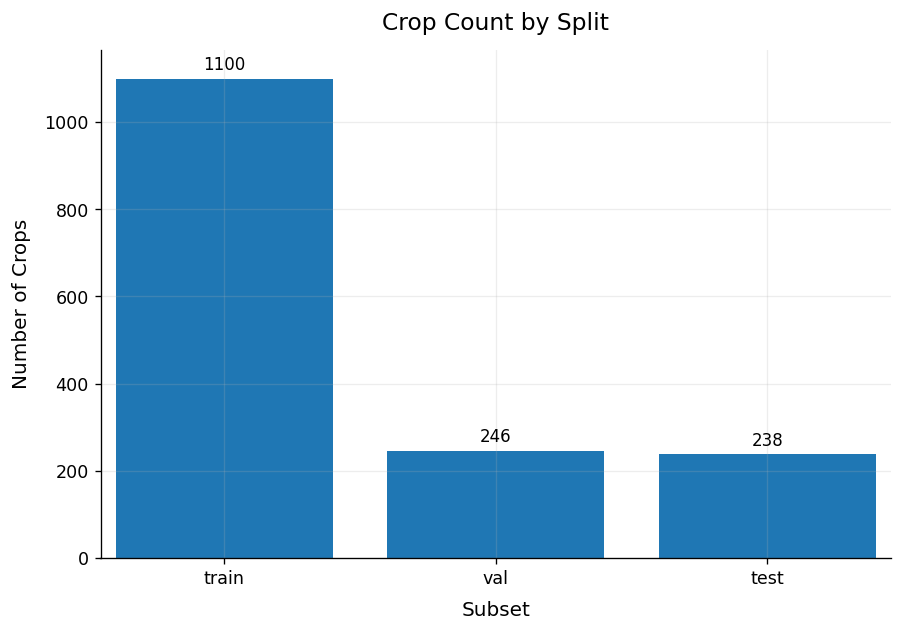

In [6]:
# We display the crop counts by split as a clean bar chart so we can inspect the final subset sizes.

import matplotlib.pyplot as plt

from src.utils import styleAxes

subsetOrder = ["train", "val", "test"]
plotDf = cropSplitCountsDf.copy()
plotDf["subset"] = pd.Categorical(plotDf["subset"], categories=subsetOrder, ordered=True)
plotDf = plotDf.sort_values("subset").reset_index(drop=True)

fig, ax = plt.subplots()

ax.bar(plotDf["subset"], plotDf["cropCount"])

styleAxes(
    ax=ax,
    title="Crop Count by Split",
    xLabel="Subset",
    yLabel="Number of Crops",
)

for barObject, countValue in zip(ax.patches, plotDf["cropCount"]):
    ax.text(
        barObject.get_x() + barObject.get_width() / 2,
        barObject.get_height() + max(plotDf["cropCount"]) * 0.01,
        str(int(countValue)),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.show()

In [7]:
# We save the approved split-count figure to the crop EDA figure directory.

splitCountFigurePath = saveFigure(
    fig=fig,
    outputDir=cropEdaFigureDir,
    figureFileName="crop_count_by_split.png",
    closeFigure=False,
)

print("Saved figure:", splitCountFigurePath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/cropEDA/crop_count_by_split.png


**Interpretation**

The split plot confirms that crop extraction preserved the original source-image split.

Most crops belong to the training set, while the validation and test sets are much smaller and are also close to each other in size. This is expected because the original dataset already provided a much larger training subset than validation and test.

This distribution is not a methodological problem, but it means that the validation and test estimates may be more sensitive to class imbalance and individual hard examples than the training set. So later model evaluation should be interpreted with this subset-size difference in mind.

### Figure 3 — Class Proportions Within Each Split

We now inspect the class proportions inside each split using a heatmap. This makes differences across train, validation, and test easier to compare without hiding the fact that the split sizes themselves are different.

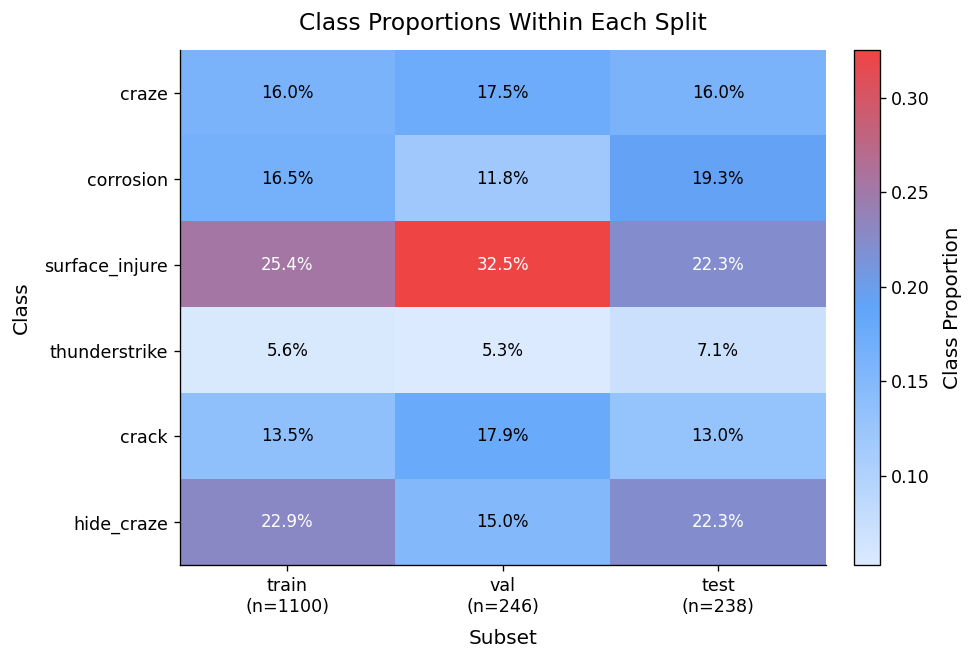

In [8]:
# We display split-wise class proportions as a cleaner heatmap with a blue-to-red scale and no cell grid lines.

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

classOrder = projectConfig.classNames
subsetOrder = ["train", "val", "test"]

plotDf = cropClassBySplitCountsDf.copy()
plotDf["subset"] = pd.Categorical(plotDf["subset"], categories=subsetOrder, ordered=True)
plotDf["className"] = pd.Categorical(plotDf["className"], categories=classOrder, ordered=True)
plotDf = plotDf.sort_values(["className", "subset"]).reset_index(drop=True)

countPivotDf = plotDf.pivot(
    index="className",
    columns="subset",
    values="cropCount",
).loc[classOrder, subsetOrder]

subsetTotals = countPivotDf.sum(axis=0)
ratioPivotDf = countPivotDf.div(subsetTotals, axis=1)

columnLabels = [
    f"train\n(n={int(subsetTotals['train'])})",
    f"val\n(n={int(subsetTotals['val'])})",
    f"test\n(n={int(subsetTotals['test'])})",
]

customCmap = LinearSegmentedColormap.from_list(
    "softBlueRed",
    ["#dbeafe", "#60a5fa", "#ef4444"],
)

fig, ax = plt.subplots(figsize=(8.2, 5.6))

imageObject = ax.imshow(
    ratioPivotDf.values,
    aspect="auto",
    cmap=customCmap,
    interpolation="nearest",
)

styleAxes(
    ax=ax,
    title="Class Proportions Within Each Split",
    xLabel="Subset",
    yLabel="Class",
)

ax.grid(False)

ax.set_xticks(np.arange(len(subsetOrder)))
ax.set_xticklabels(columnLabels)
ax.set_yticks(np.arange(len(classOrder)))
ax.set_yticklabels(classOrder)

for rowIndex in range(ratioPivotDf.shape[0]):
    for colIndex in range(ratioPivotDf.shape[1]):
        ratioValue = ratioPivotDf.iloc[rowIndex, colIndex]
        textColor = "white" if ratioValue >= 0.22 else "black"
        ax.text(
            colIndex,
            rowIndex,
            f"{ratioValue:.1%}",
            ha="center",
            va="center",
            fontsize=10,
            color=textColor,
        )

colorbarObject = fig.colorbar(imageObject, ax=ax, fraction=0.046, pad=0.04)
colorbarObject.set_label("Class Proportion")

plt.tight_layout()
plt.show()

In [9]:
# We save the approved split-composition heatmap to the crop EDA figure directory.

classCompositionHeatmapPath = saveFigure(
    fig=fig,
    outputDir=cropEdaFigureDir,
    figureFileName="class_proportions_within_each_split.png",
    closeFigure=False,
)

print("Saved figure:", classCompositionHeatmapPath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/cropEDA/class_proportions_within_each_split.png


**Interpretation**

The heatmap shows that the class composition is broadly similar across the three splits, but it is not perfectly identical.

The clearest deviation appears in `surface_injure`, which occupies a noticeably larger share of the validation set than of the training and test sets. We also see some smaller proportion shifts in classes such as `corrosion`, `crack`, and `hide_craze`. In contrast, `thunderstrike` remains a minority class in all three splits.

This means the provided split is usable, but it is not perfectly stratified at the crop level. So later model evaluation should take class imbalance and split-level proportion differences into account. In particular, we should rely on class-sensitive metrics such as macro F1, per-class recall, and the confusion matrix rather than judging performance only from overall accuracy.

### Figure 4 — Crop Width and Height Distribution

We now inspect the width and height distributions of the extracted crops. This helps us understand whether the crop dataset contains very small, very large, or strongly elongated object regions before modeling.

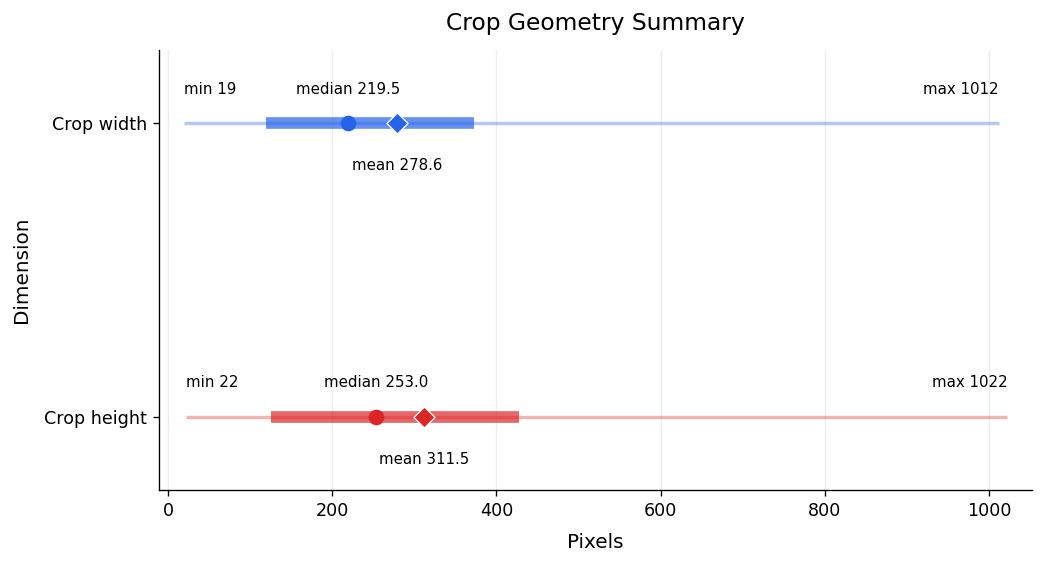

In [10]:
# We display a compact geometry summary for crop width and crop height using min, quartiles, median, mean, and max.

import matplotlib.pyplot as plt
import pandas as pd

summaryDf = pd.DataFrame(
    {
        "dimension": ["cropWidth", "cropHeight"],
        "minValue": [cropManifestDf["cropWidth"].min(), cropManifestDf["cropHeight"].min()],
        "q1Value": [cropManifestDf["cropWidth"].quantile(0.25), cropManifestDf["cropHeight"].quantile(0.25)],
        "medianValue": [cropManifestDf["cropWidth"].median(), cropManifestDf["cropHeight"].median()],
        "meanValue": [cropManifestDf["cropWidth"].mean(), cropManifestDf["cropHeight"].mean()],
        "q3Value": [cropManifestDf["cropWidth"].quantile(0.75), cropManifestDf["cropHeight"].quantile(0.75)],
        "maxValue": [cropManifestDf["cropWidth"].max(), cropManifestDf["cropHeight"].max()],
    }
)

fig, ax = plt.subplots(figsize=(8.8, 4.8))

yPositions = [1, 0]
colorMap = {
    "cropWidth": "#2563eb",
    "cropHeight": "#dc2626",
}

for rowIndex, (_, row) in enumerate(summaryDf.iterrows()):
    dimensionName = row["dimension"]
    currentColor = colorMap[dimensionName]
    yValue = yPositions[rowIndex]

    ax.hlines(
        y=yValue,
        xmin=row["minValue"],
        xmax=row["maxValue"],
        color=currentColor,
        linewidth=2.0,
        alpha=0.35,
    )

    ax.hlines(
        y=yValue,
        xmin=row["q1Value"],
        xmax=row["q3Value"],
        color=currentColor,
        linewidth=7.0,
        alpha=0.7,
    )

    ax.scatter(
        row["medianValue"],
        yValue,
        color=currentColor,
        s=70,
        marker="o",
        label=f"{dimensionName} median" if rowIndex == 0 else None,
        zorder=3,
    )

    ax.scatter(
        row["meanValue"],
        yValue,
        color=currentColor,
        s=80,
        marker="D",
        edgecolor="white",
        linewidth=0.8,
        label=f"{dimensionName} mean" if rowIndex == 0 else None,
        zorder=3,
    )

    ax.text(row["minValue"], yValue + 0.10, f"min {row['minValue']:.0f}", fontsize=9, ha="left")
    ax.text(row["medianValue"], yValue + 0.10, f"median {row['medianValue']:.1f}", fontsize=9, ha="center")
    ax.text(row["meanValue"], yValue - 0.16, f"mean {row['meanValue']:.1f}", fontsize=9, ha="center")
    ax.text(row["maxValue"], yValue + 0.10, f"max {row['maxValue']:.0f}", fontsize=9, ha="right")

ax.set_yticks(yPositions)
ax.set_yticklabels(["Crop width", "Crop height"])

styleAxes(
    ax=ax,
    title="Crop Geometry Summary",
    xLabel="Pixels",
    yLabel="Dimension",
)

ax.margins(x=0.03, y=0.25)
ax.grid(axis="x", alpha=0.22)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

In [11]:
# We save the approved crop-geometry summary figure to the crop EDA figure directory.

cropGeometrySummaryPath = saveFigure(
    fig=fig,
    outputDir=cropEdaFigureDir,
    figureFileName="crop_geometry_summary.png",
    closeFigure=False,
)

print("Saved figure:", cropGeometrySummaryPath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/cropEDA/crop_geometry_summary.png


**Interpretation**

The crop geometry summary shows that both width and height vary strongly across the dataset.

The minimum values are very small, while the maximum values are close to the full image scale. This confirms that the crop dataset contains a mixture of compact defect regions, large damaged areas, and elongated blade-related crops. We also observe that the mean is higher than the median for both dimensions, which indicates a right-skewed size distribution with some very large crops pulling the average upward.

Overall, crop height is slightly larger than crop width in the central tendency statistics, but both dimensions span a broad range. This means the modeling pipeline must handle substantial variation in crop geometry, even though all inputs will later be resized to a fixed model size.

### Figure 5 — Representative Crops by Geometry

We now inspect actual crop examples that correspond to minimum, median, and maximum cases for crop width and crop height. This helps us connect the geometry summary to real visual examples from the dataset.

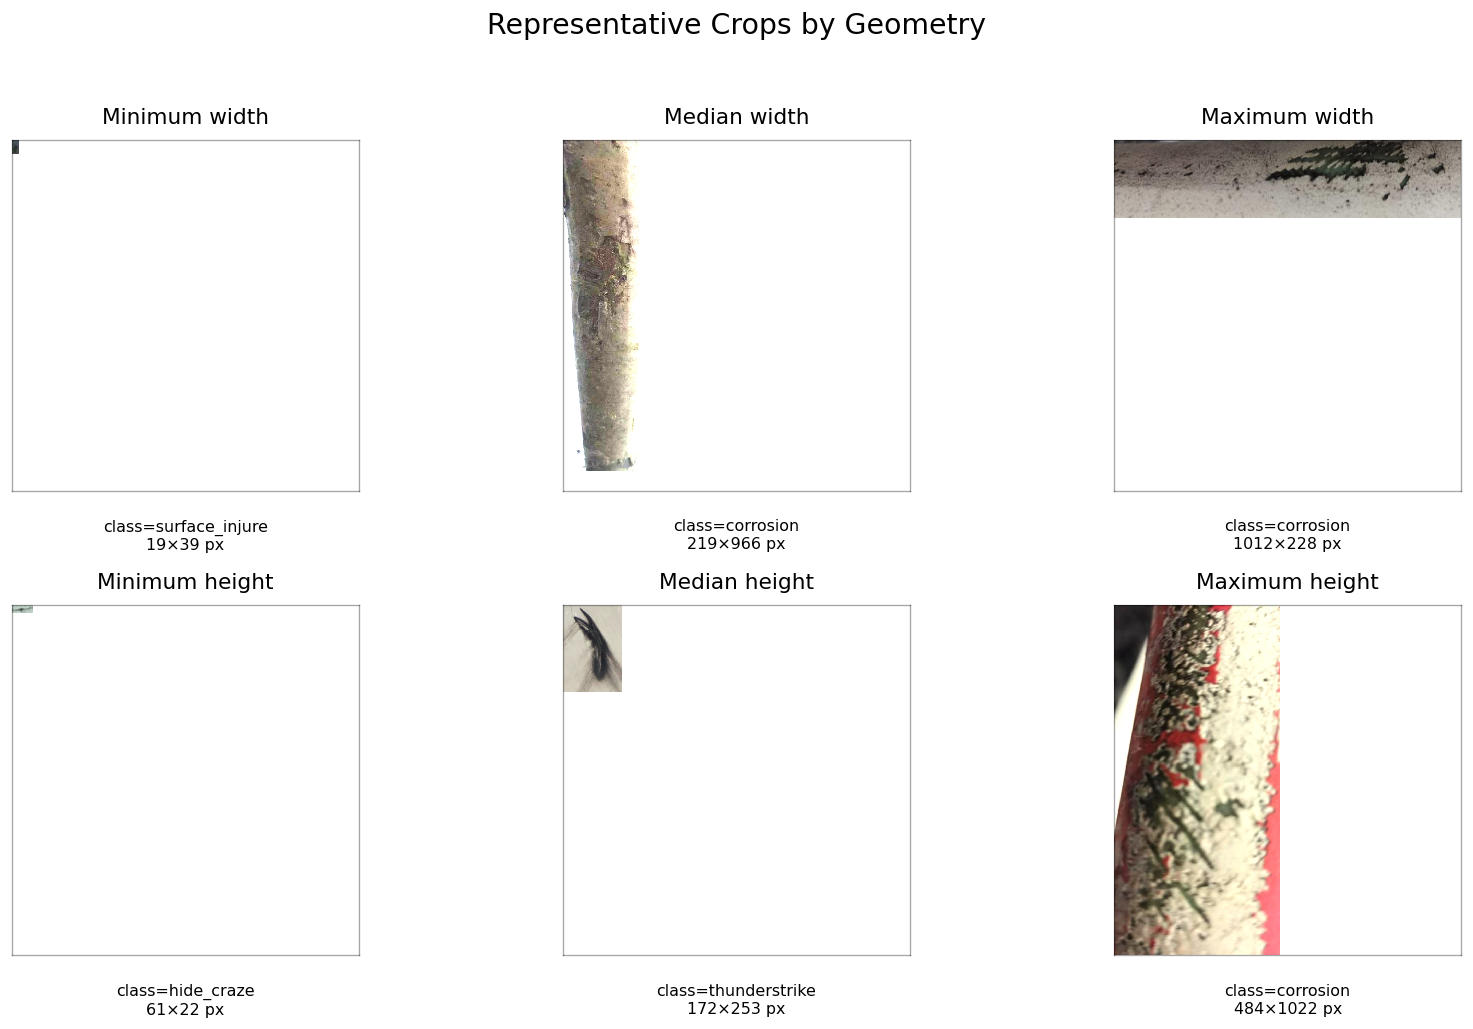

In [12]:
# We display representative crops on a shared pixel canvas so their relative sizes remain visually meaningful.

import matplotlib.pyplot as plt
from PIL import Image


def getRepresentativeCropRow(dataframe: pd.DataFrame, columnName: str, targetMode: str) -> pd.Series:
    """We select one representative crop row for a minimum, median, or maximum case of a chosen geometry column."""
    if targetMode == "min":
        selectedIndex = dataframe[columnName].idxmin()
    elif targetMode == "max":
        selectedIndex = dataframe[columnName].idxmax()
    elif targetMode == "median":
        medianValue = dataframe[columnName].median()
        selectedIndex = (dataframe[columnName] - medianValue).abs().idxmin()
    else:
        raise ValueError(f"Unsupported targetMode: {targetMode}")

    return dataframe.loc[selectedIndex]


representativeCropSpecs = [
    ("cropWidth", "min", "Minimum width"),
    ("cropWidth", "median", "Median width"),
    ("cropWidth", "max", "Maximum width"),
    ("cropHeight", "min", "Minimum height"),
    ("cropHeight", "median", "Median height"),
    ("cropHeight", "max", "Maximum height"),
]

representativeCropRows = []
for columnName, targetMode, displayLabel in representativeCropSpecs:
    selectedRow = getRepresentativeCropRow(
        dataframe=cropManifestDf,
        columnName=columnName,
        targetMode=targetMode,
    )
    representativeCropRows.append((displayLabel, selectedRow))

globalMaxWidth = int(cropManifestDf["cropWidth"].max())
globalMaxHeight = int(cropManifestDf["cropHeight"].max())

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, (displayLabel, selectedRow) in zip(axes, representativeCropRows):
    cropImage = Image.open(selectedRow["cropPath"]).convert("RGB")

    cropWidth = int(selectedRow["cropWidth"])
    cropHeight = int(selectedRow["cropHeight"])

    ax.imshow(
        cropImage,
        extent=[0, cropWidth, cropHeight, 0],
        interpolation="nearest",
    )

    ax.set_xlim(0, globalMaxWidth)
    ax.set_ylim(globalMaxHeight, 0)

    ax.set_title(displayLabel, fontsize=13, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_alpha(0.35)

    ax.text(
        0.5,
        -0.08,
        (
            f"class={selectedRow['className']}\n"
            f"{cropWidth}×{cropHeight} px"
        ),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9.5,
    )

fig.suptitle("Representative Crops by Geometry", fontsize=17, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [13]:
# We save the approved representative-crops panel to the crop EDA figure directory.

representativeCropGeometryPath = saveFigure(
    fig=fig,
    outputDir=cropEdaFigureDir,
    figureFileName="representative_crops_by_geometry.png",
    closeFigure=False,
)

print("Saved figure:", representativeCropGeometryPath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/cropEDA/representative_crops_by_geometry.png


**Interpretation**

This panel shows representative crops on a shared pixel canvas, so their relative sizes remain visually meaningful.

The minimum-size examples appear extremely small compared with the full geometry range, while the maximum-size examples occupy a large part of the shared canvas. The median cases sit between these extremes and are visually more representative of the typical crop scale.

This confirms that the crop dataset contains strong variation in both scale and aspect ratio. Some crops are very compact, some are strongly elongated, and some cover large damaged blade regions. This is not a pipeline error. It reflects the real annotation geometry of the dataset and shows that the later modeling stage must handle substantial variation in crop shape and size after resizing to a fixed input size.

### Figure 6 — Duplicate-Risk Summary

We now inspect the number of crops that are associated with duplicate-risk cases. This helps us separate general dataset size from the small subset of cases that need special care in the final modeling and evaluation stage.

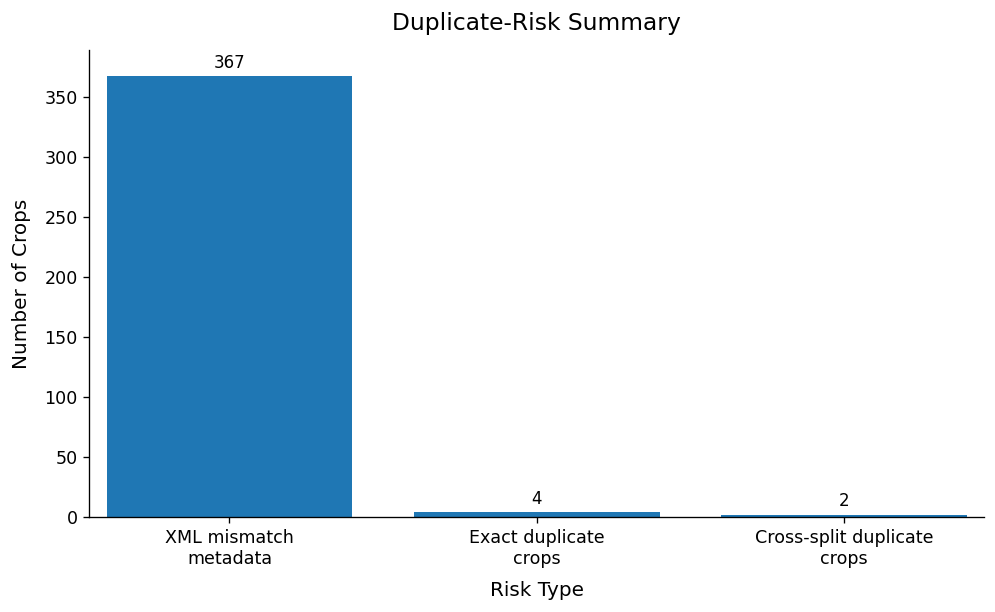

In [15]:
# We display the duplicate-risk counts as a compact bar chart so the leakage-related cases are easy to compare.

import matplotlib.pyplot as plt

duplicateRiskPlotDf = pd.DataFrame(
    {
        "riskType": [
            "XML mismatch\nmetadata",
            "Exact duplicate\ncrops",
            "Cross-split duplicate\ncrops",
        ],
        "countValue": [
            cropBuildSummary["mismatchCropCount"],
            cropBuildSummary["exactDuplicateCropCount"],
            cropBuildSummary["crossSplitDuplicateCropCount"],
        ],
    }
)

fig, ax = plt.subplots(figsize=(8.4, 5.2))

ax.bar(
    duplicateRiskPlotDf["riskType"],
    duplicateRiskPlotDf["countValue"],
)

styleAxes(
    ax=ax,
    title="Duplicate-Risk Summary",
    xLabel="Risk Type",
    yLabel="Number of Crops",
)

ax.grid(False)

for barObject, countValue in zip(ax.patches, duplicateRiskPlotDf["countValue"]):
    ax.text(
        barObject.get_x() + barObject.get_width() / 2,
        barObject.get_height() + max(duplicateRiskPlotDf["countValue"]) * 0.01,
        str(int(countValue)),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

In [16]:
# We save the approved duplicate-risk summary figure to the crop EDA figure directory.

duplicateRiskFigurePath = saveFigure(
    fig=fig,
    outputDir=cropEdaFigureDir,
    figureFileName="duplicate_risk_summary.png",
    closeFigure=False,
)

print("Saved figure:", duplicateRiskFigurePath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/cropEDA/duplicate_risk_summary.png


**Interpretation**

The duplicate-risk summary shows that the three risk types do not have the same practical meaning.

The largest count comes from XML mismatch metadata, but this does not mean the crops are visually incorrect. Earlier audit and overlay validation showed that this issue comes from inconsistent internal XML filename metadata, while stem-based matching still maps annotations to the correct real images.

In contrast, the exact-duplicate and cross-split duplicate cases are very small in number. This is important because these are the cases that matter most for leakage control in the modeling stage. Since the counts are low and already tracked in the crop manifest, we can handle them explicitly without changing the raw dataset itself.

So, from a modeling perspective, the main leakage-related concern is limited and manageable, while the XML mismatch issue is primarily a metadata-quality issue rather than a crop-generation failure.

### Figure 7 — Representative Crops by Class

We now inspect one representative crop per class so we can connect the class labels to actual visual examples from the extracted crop dataset.

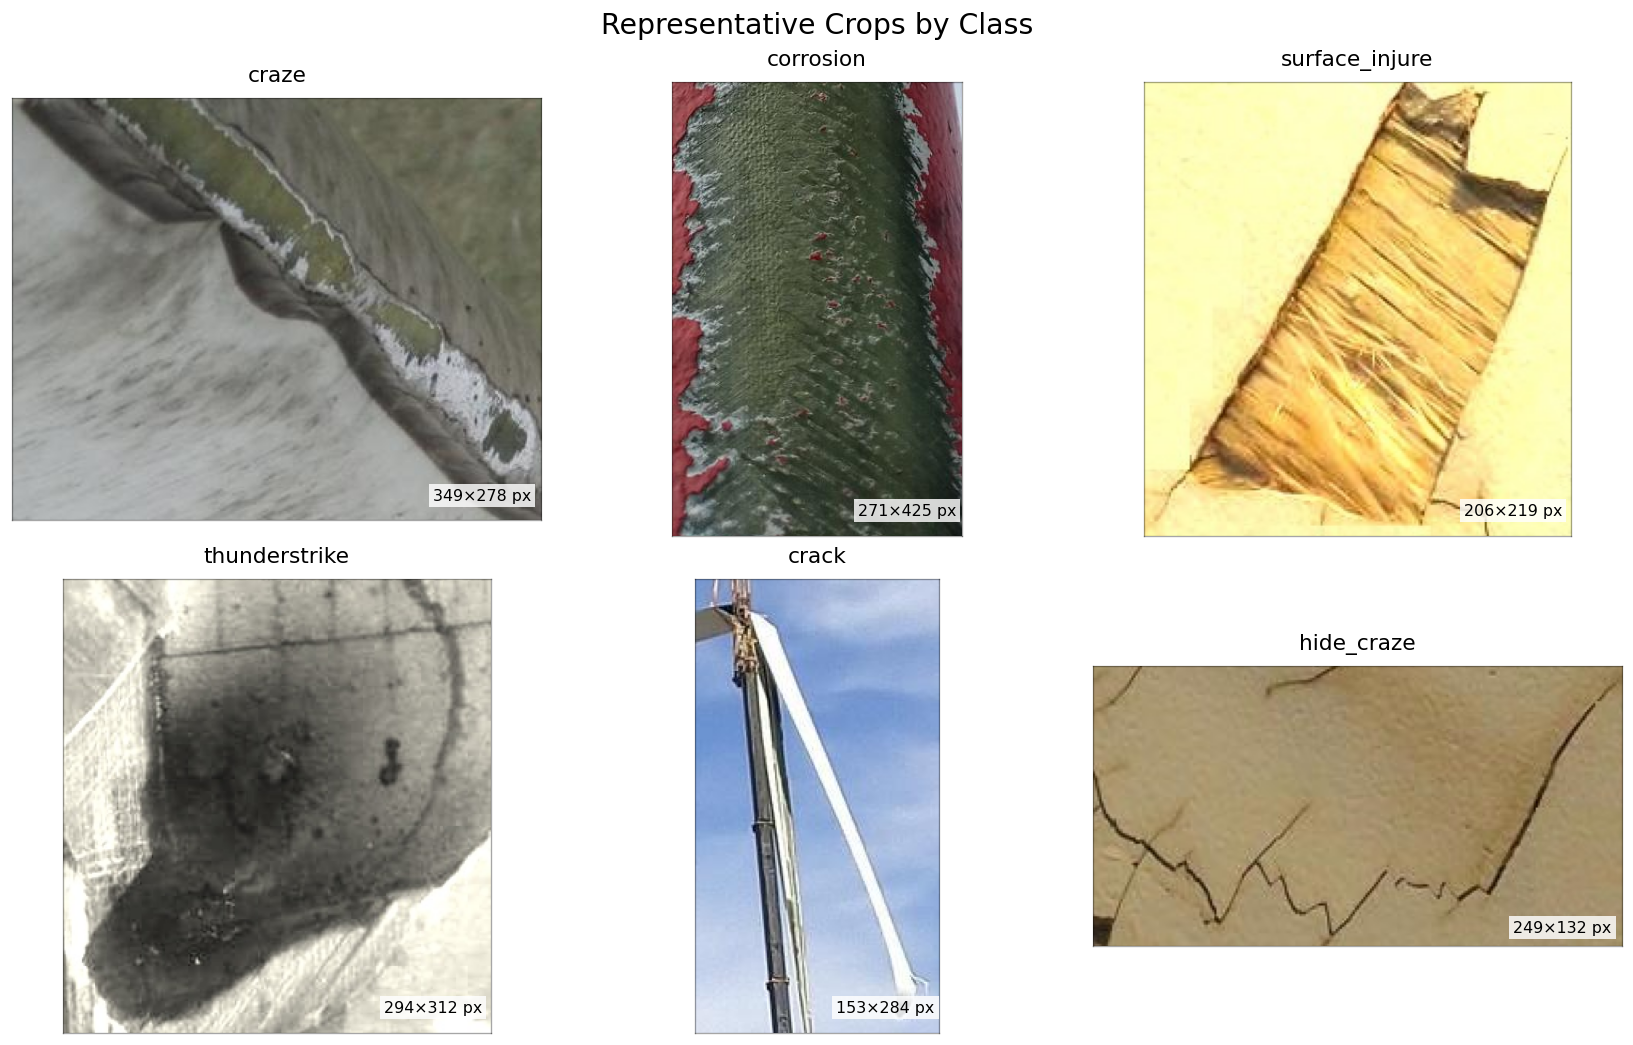

In [18]:
# We display one cleaner representative crop per class by preferring crops that are both typical in geometry and visually sharper.

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def computeSharpnessScore(imagePath: str) -> float:
    """We compute a simple sharpness score from grayscale intensity differences."""
    grayscaleArray = np.asarray(Image.open(imagePath).convert("L"), dtype=np.float32)

    if grayscaleArray.shape[0] < 2 or grayscaleArray.shape[1] < 2:
        return 0.0

    diffY = np.abs(np.diff(grayscaleArray, axis=0)).mean()
    diffX = np.abs(np.diff(grayscaleArray, axis=1)).mean()

    return float(diffX + diffY)


def getRepresentativeClassCropRow(dataframe: pd.DataFrame, className: str, candidateCount: int = 20) -> pd.Series:
    """We select one representative crop for a class by combining geometric typicality with visual sharpness."""
    classDf = dataframe.loc[dataframe["className"] == className].copy().reset_index(drop=True)

    classDf["logArea"] = np.log(classDf["cropArea"].astype(float))
    classDf["logAspect"] = np.log(classDf["cropWidth"].astype(float) / classDf["cropHeight"].astype(float))

    medianLogArea = classDf["logArea"].median()
    medianLogAspect = classDf["logAspect"].median()

    classDf["distanceScore"] = (
        (classDf["logArea"] - medianLogArea).abs()
        + (classDf["logAspect"] - medianLogAspect).abs()
    )

    candidateDf = classDf.nsmallest(min(candidateCount, len(classDf)), "distanceScore").copy()
    candidateDf["sharpnessScore"] = candidateDf["cropPath"].apply(computeSharpnessScore)

    selectedIndex = candidateDf["sharpnessScore"].idxmax()
    return candidateDf.loc[selectedIndex]


classOrder = projectConfig.classNames
representativeClassRows = [
    getRepresentativeClassCropRow(cropManifestDf, className)
    for className in classOrder
]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6), constrained_layout=True)
axes = axes.flatten()

for ax, selectedRow in zip(axes, representativeClassRows):
    cropImage = Image.open(selectedRow["cropPath"]).convert("RGB")

    ax.imshow(cropImage)
    ax.set_title(str(selectedRow["className"]), fontsize=13, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_alpha(0.35)

    ax.text(
        0.98,
        0.04,
        f"{int(selectedRow['cropWidth'])}×{int(selectedRow['cropHeight'])} px",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9.5,
        bbox=dict(
            facecolor="white",
            alpha=0.82,
            edgecolor="none",
            pad=2.5,
        ),
    )

fig.suptitle("Representative Crops by Class", fontsize=17)
plt.show()

In [19]:
# We save the approved representative-crops-by-class panel to the crop EDA figure directory.

representativeClassCropPath = saveFigure(
    fig=fig,
    outputDir=cropEdaFigureDir,
    figureFileName="representative_crops_by_class.png",
    closeFigure=False,
)

print("Saved figure:", representativeClassCropPath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/cropEDA/representative_crops_by_class.png


**Interpretation**

This panel gives one representative crop example for each defect class and makes the visual differences between the categories more concrete.

Some classes appear as narrow line-like structures, some as localized damaged regions, and some as larger textured surface changes. We also see that the classes differ not only in visual appearance but also in crop geometry and background context. This helps explain why the classification task is not trivial even when the crops are extracted correctly.

Overall, the panel supports the idea that the dataset contains meaningful visual class structure, while also showing that some categories may be harder to separate because defect appearance, scale, and surrounding blade context can vary substantially.

### Crop EDA Conclusion

The crop-level EDA shows that the extracted crop dataset is usable for modeling, but it also reveals several properties that we need to keep in mind.

The main findings are:

- the crop dataset is class-imbalanced, with `surface_injure` and `hide_craze` appearing more often than `thunderstrike`
- the train, validation, and test splits are usable, but their class proportions are not perfectly identical
- crop geometry varies strongly, including compact crops, elongated crops, and large damaged blade regions
- duplicate-risk cases are present but very limited in number and are already tracked in the crop manifest
- representative crop examples show meaningful visual structure for all classes, but also confirm that the classification task is visually non-trivial

From these observations, we conclude that the dataset is suitable for downstream modeling, but evaluation should rely on class-sensitive metrics rather than overall accuracy alone. The later modeling stage should also remain aware of class imbalance, crop-geometry variation, and the small number of duplicate-risk cases.